# SQL Assignment: Analyzing Startup Investments
**Author:** Tina Marie Wilken    
**Dialect:** SQLPad (PostgreSQL-compatible syntax)  
**Tools:** SQLPad  
**Dataset:** Alvarez, R. (2026). Crunchbase [Data set]. Coding for Data, Global Career Accelerators. https://globalcareeraccelerator.org/    
**Date:** September 2, 2026

## Overview
**This notebook contains solutions to the SQL mini-project Milestone:**

Crunchbase is a platform that provides information and news on companies and investors, primarily in the startup and technology space. Over the past decade, it has become a popular business tool and a vital resource for entrepreneurs and those trying to assess startup companies.

Startups hardly ever go it alone. They need investors to give them money in order to develop their products, expand, and build enough momentum to be successful. For this Milestone, you'll take on the role of a strategic advisor to a global venture capital firm, using data analysis to evaluate and advise on high-potential startups for investment.  

## Dataset Description
Your first step in any data project is to understand the data at your disposal. The Crunchbase "company investments" data set (`crunchbase.companies`) is a single table with 20 columns and over 27 000 rows.

Here are columns that you’ll be using in this Milestone:
- `name` - Company’s name.
- `category_code` - The company’s main industry, market, or business area.
- `status` - The company’s status. Can be "operating", "ipo", "acquired", or "closed".
- `funding_total_usd` - Total funding received by the company over their entire existence. Many of the later numeric columns in the dataset break down this total into component sources.


---

### Task 1: Top Funded Companies
**A.** Write a query that returns the `name`, `category_code`, `status`, and `funding_total_usd` for the twelve companies with the highest amount of funding. 

*My SQL Code*
<pre style="background-color: #f8f9fa; color: #24292e; padding: 14px; border-radius: 6px; font-family: 'Consolas', 'Courier New', monospace; font-size: 13px; line-height: 1.5; border: 1px solid #e1e4e8;"><code><span style="color: #0000ff; font-weight: bold;">SELECT</span>
    name,
    category_code,
    status,
    funding_total_usd
<span style="color: #0000ff; font-weight: bold;">FROM</span> crunchbase.companies
<span style="color: #0000ff; font-weight: bold;">WHERE</span> funding_total_usd <span style="color: #0000ff; font-weight: bold;">IS NOT NULL</span>
<span style="color: #0000ff; font-weight: bold;">ORDER BY</span> funding_total_usd <span style="color: #0000ff; font-weight: bold;">DESC</span>;</co de></pre>

Task 1A Results
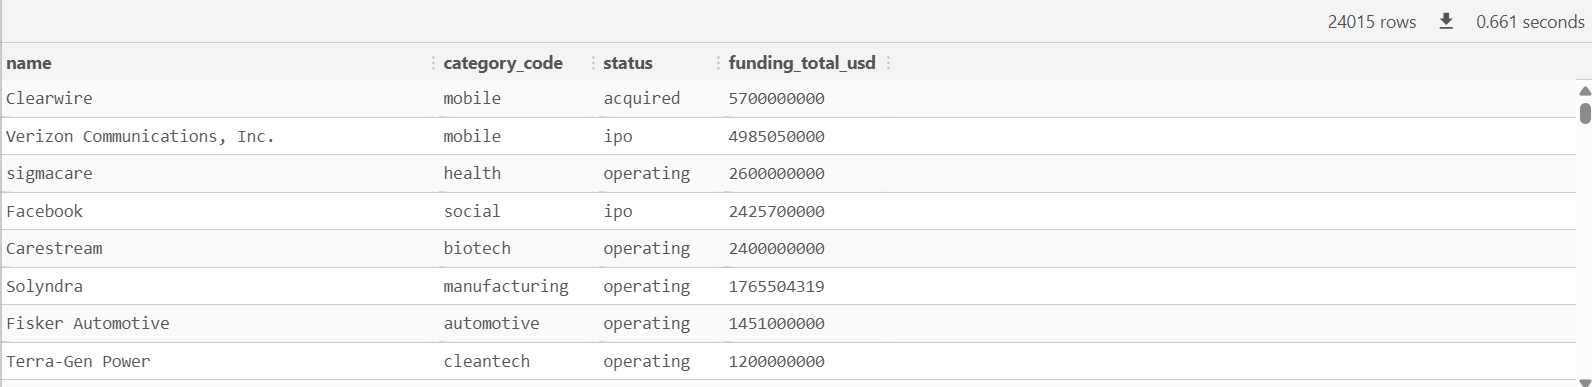

<br>

**B:** Check the data returned from your query. What is the name of the company with the highest funding?

**Answer:** Clearwire, a mobile company, with \$5,700,000,000 in total funding.

<br>

**C.** Compare the funding received by the top-funded company and the twelfth-most-funded company (at the end of the output). How much more did the number 1 company receive? HINT: Calculate your answer in terms of the ratio, by dividing the larger amount by the smaller amount; you don’t need to do that calculation with a query.

**Answer:** The 12th most funded company was Blackberry, a hardware company that received \$1,000,000,000 in total funding.

$$\frac{5,700,000,000}{1,000,000,000} = 5.7 = 570\%$$

* **Ratio:** Clearwire received 5.7× (or 570% of) Blackberry's funding.
* **Percentage more:** Clearwire received 470% more funding than Blackberry:
  $$\frac{5,700,000,000 - 1,000,000,000}{1,000,000,000} \times 100\% = 470\%$$

<br>

**D.** How many companies in the top twelve have a listed status of <span style="font-family: 'Courier New', Courier, monospace;">'acquired'</span> rather than <span style="font-family: 'Courier New', Courier, monospace;">'operating'</span> or <span style="font-family: 'Courier New', Courier, monospace;">'ipo'</span>? NOTE: you do not need to write a SQL query to answer this question!

**Answer:** Only one company in the top 12 was acquired and that was Clearwire.

---

### Task 2: Top Closed Companies
Among the top twelve companies, none were listed as <span style="font-family: 'Courier New', Courier, monospace;">'closed'</span>, meaning the company has stopped operating. Let’s focus on companies with that status next.

**A.** Modify your query from Task 1A to view only companies with a <span style="font-family: 'Courier New', Courier, monospace;">'closed'</span> status . In other words, retrieve the twelve companies that received the most funding but whose status is closed.

*My SQL Code*
<pre style="background-color: #f8f9fa; color: #24292e; padding: 14px; border-radius: 6px; font-family: 'Consolas', 'Courier New', monospace; font-size: 13px; line-height: 1.5; border: 1px solid #e1e4e8;"><code><span style="color: #0000ff; font-weight: bold;">SELECT</span>
    name,
    category_code,
    status,
    funding_total_usd
<span style="color: #0000ff; font-weight: bold;">FROM</span> crunchbase.companies
<span style="color: #0000ff; font-weight: bold;">WHERE</span> funding_total_usd <span style="color: #0000ff; font-weight: bold;">IS NOT NULL</span>
    <span style="color: #0000ff; font-weight: bold;">AND</span> status = <span style="color: #a31515;">'closed'</span>
<span style="color: #0000ff; font-weight: bold;">ORDER BY</span> funding_total_usd <span style="color: #0000ff; font-weight: bold;">DESC</span>
<span style="color: #0000ff; font-weight: bold;">LIMIT</span> <span style="color: #098658;">12</span>;</code></pre>

Task 2A Results
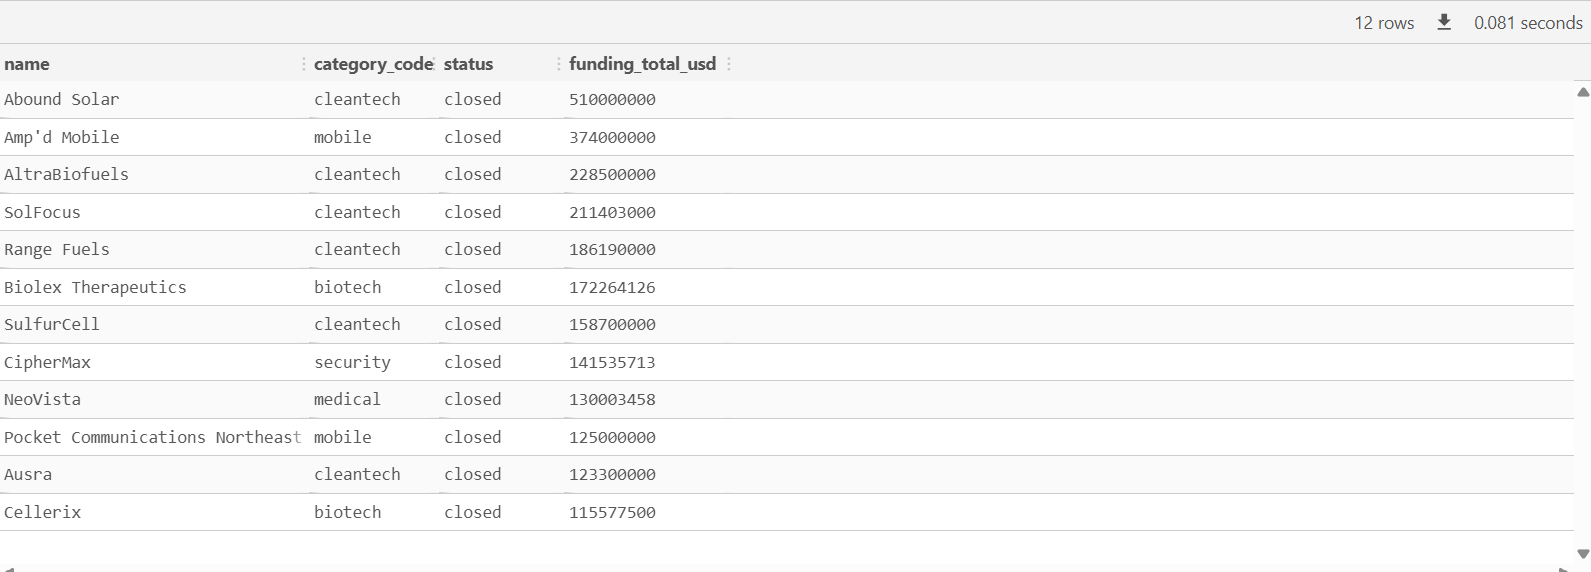

<br>

**B.** What is the name of the company with the highest funding that closed down?

**Answer:** Abound Solar, a cleantech company, with \$510,000,000 in total funding.

<br>

**C.** How much funding did they receive?

**Answer:** \$510,000,000 in total funding.

<br>

**D.** The <span style="font-family: 'Courier New', Courier, monospace;">'cleantech'</span> category shows up multiple times in the top twelve. How many of the closed companies in the top twelve come from this category? NOTE: you do not need to write a SQL query to answer this question!

**Answer:** There are six companies that are in the <span style="font-family: 'Courier New', Courier, monospace;">'cleantech'</span> category.

---

### Task 3: Deeper Into Clean Technology
The fact that a lot of highly-funded companies that have a status of <span style="font-family: 'Courier New', Courier, monospace;">'closed'</span> came from cleantech seems like an interesting thread to pull at, so let’s look at them a bit more.

**A.** Let’s take a step back first. Write a query that returns the `name`, `category_code`, and `status` of companies with the <span style="font-family: 'Courier New', Courier, monospace;">'cleantech'</span> category code.

*My SQL Code*
<pre style="background-color: #f8f9fa; color: #24292e; padding: 14px; border-radius: 6px; font-family: 'Consolas', 'Courier New', monospace; font-size: 13px; line-height: 1.5; border: 1px solid #e1e4e8;"><code><span style="color: #0000ff; font-weight: bold;">SELECT</span>
    name,
    category_code,
    status,
    funding_total_usd
<span style="color: #0000ff; font-weight: bold;">FROM</span> crunchbase.companies
<span style="color: #0000ff; font-weight: bold;">WHERE</span> funding_total_usd <span style="color: #0000ff; font-weight: bold;">IS NOT NULL</span>
    <span style="color: #0000ff; font-weight: bold;">AND</span> category_code = <span style="color: #a31515;">'cleantech'</span>;</code></pre>

Task 3A Query Results
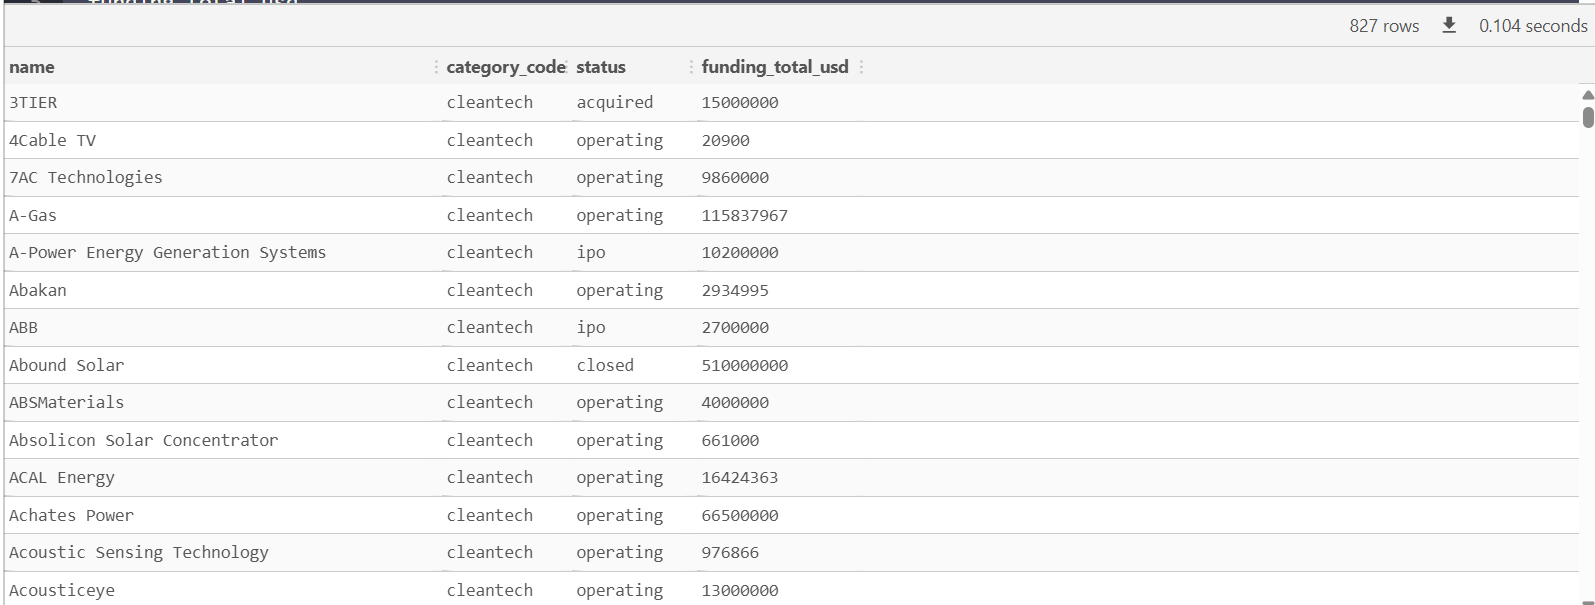

<br>

How many companies have <span style="font-family: 'Courier New', Courier, monospace;">'cleantech'</span> as the main market category? Use the information bar above the output to see the number of rows in the output.,

<br>

**Answer:** There are 827 companies designated as <span style="font-family: 'Courier New', Courier, monospace;">'cleantech'</span>.

<br>

**B.** About 7.9% of all companies in the full data table are listed with a <span style="font-family: 'Courier New', Courier, monospace;">'closed'</span> status. Add an additional condition to your query to only look at closed, <span style="font-family: 'Courier New', Courier, monospace;">'cleantech'</span> companies.

*My SQL Code*
<pre style="background-color: #f8f9fa; color: #24292e; padding: 14px; border-radius: 6px; font-family: 'Consolas', 'Courier New', monospace; font-size: 13px; line-height: 1.5; border: 1px solid #e1e4e8;"><code><span style="color: #0000ff; font-weight: bold;">SELECT</span>
    name,
    category_code,
    status,
    funding_total_usd
<span style="color: #0000ff; font-weight: bold;">FROM</span> crunchbase.companies
<span style="color: #0000ff; font-weight: bold;">WHERE</span> funding_total_usd <span style="color: #0000ff; font-weight: bold;">IS NOT NULL</span>
    <span style="color: #0000ff; font-weight: bold;">AND</span> category_code = <span style="color: #a31515;">'cleantech'</span>
    <span style="color: #0000ff; font-weight: bold;">AND</span> status = <span style="color: #a31515;">'closed'</span>;</code></pre>

Task 3B Query Results
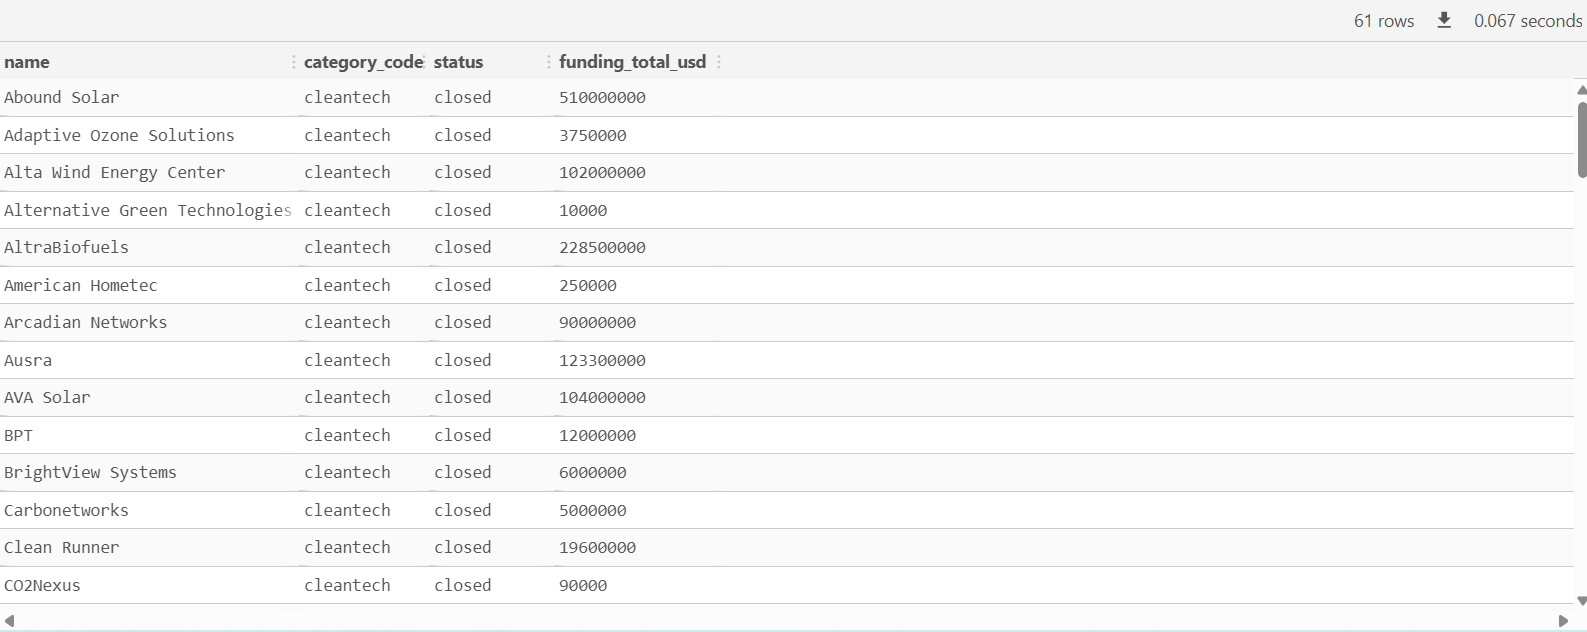

<br>

What percentage of <span style="font-family: 'Courier New', Courier, monospace;">'cleantech'</span> companies have a closed status, and how does this compare to the data as a whole? HINT: You’ll need to use your answer from 3A.

**Answer:** 61 cleantech companies that were funded closed. That’s 7.38% of total funded cleantech companies.

---

### LevelUp
**A.** To close things out, let’s be a little creative and look at company names just for fun. How many <span style="font-family: 'Courier New', Courier, monospace;">'cleantech'</span> category companies have <span style="font-family: 'Courier New', Courier, monospace;">'solar'</span>, <span style="font-family: 'Courier New', Courier, monospace;">'power'</span>, or <span style="font-family: 'Courier New', Courier, monospace;">'energy'</span> in their names? 

*My SQL Code*
<pre style="background-color: #f8f9fa; color: #24292e; padding: 14px; border-radius: 6px; font-family: 'Consolas', 'Courier New', monospace; font-size: 13px; line-height: 1.5; border: 1px solid #e1e4e8;"><code><span style="color: #0000ff; font-weight: bold;">SELECT</span>
    name,
    category_code
<span style="color: #0000ff; font-weight: bold;">FROM</span> crunchbase.companies
<span style="color: #0000ff; font-weight: bold;">WHERE</span> category_code = <span style="color: #a31515;">'cleantech'</span>
    <span style="color: #0000ff; font-weight: bold;">AND</span> (name <span style="color: #0000ff; font-weight: bold;">ILIKE</span> <span style="color: #a31515;">'%solar%'</span>
    <span style="color: #0000ff; font-weight: bold;">OR</span> name <span style="color: #0000ff; font-weight: bold;">ILIKE</span> <span style="color: #a31515;">'%power%'</span>
    <span style="color: #0000ff; font-weight: bold;">OR</span> name <span style="color: #0000ff; font-weight: bold;">ILIKE</span> <span style="color: #a31515;">'%energy%'</span>);</code></pre>

LevelUp A Query Results
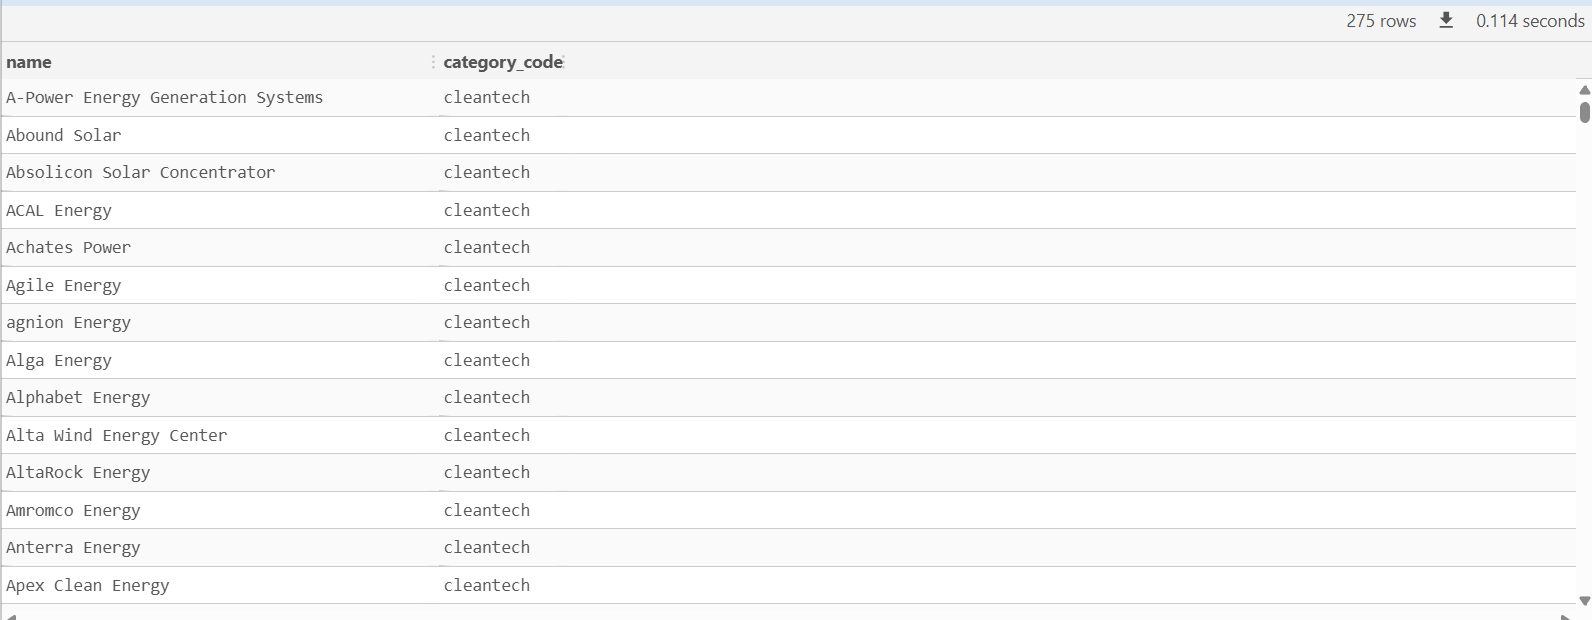

<br>

**Answer:** There are 275 companies.

---

## Change Log

| Date (YYYY-MM-DD) | Version | Changed By | Change Description |
| :--- | :--- | :--- | :--- |
| 2026-10-06 | 1.1 | Your Name | Updated text formatting for better readability, updated image paths, added change log section|
| 2026-10-05 | 1.0 | Tina Marie Wilken | Initial draft: Migrated SQL assignment from PDF to Jupyter Notebook |